In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\HP\Downloads\Eda Project\Data\processed\cleaned.csv")

df.head()


,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,...,PaymentMethod,OrderStatus,City,State,Country,SellerID,Year,Month,Day,DayOfWeek
0,ORD0000001,2023-01-31,CUST001504,Vihaan Sharma,P00014,Drone Mini,Books,BrightLux,3,106.59,...,Debit Card,Delivered,Washington,DC,India,SELL01967,2023,1,31,Tuesday
1,ORD0000002,2023-12-30,CUST000178,Pooja Kumar,P00040,Microphone,Home & Kitchen,UrbanStyle,1,251.37,...,Amazon Pay,Delivered,Fort Worth,TX,United States,SELL01298,2023,12,30,Saturday
2,ORD0000003,2022-05-10,CUST047516,Sneha Singh,P00044,Power Bank 20000mAh,Clothing,UrbanStyle,3,35.03,...,Debit Card,Delivered,Austin,TX,United States,SELL00908,2022,5,10,Tuesday
3,ORD0000004,2023-07-18,CUST030059,Vihaan Reddy,P00041,Webcam Full HD,Home & Kitchen,Zenith,5,33.58,...,Cash on Delivery,Delivered,Charlotte,NC,India,SELL01164,2023,7,18,Tuesday
4,ORD0000005,2023-02-04,CUST048677,Aditya Kapoor,P00029,T-Shirt,Clothing,KiddoFun,2,515.64,...,Credit Card,Cancelled,San Antonio,TX,Canada,SELL01411,2023,2,4,Saturday


In [4]:
df.shape

(98203, 24)

In [5]:
num_cols = df.select_dtypes(include=["number"]).columns
cat_cols = df.select_dtypes(include=["object", "string"]).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Numerical Columns: Index(['Quantity', 'UnitPrice', 'Discount', 'Tax', 'ShippingCost',
       'TotalAmount', 'Year', 'Month', 'Day'],
      dtype='str')
Categorical Columns: Index(['OrderID', 'OrderDate', 'CustomerID', 'CustomerName', 'ProductID',
       'ProductName', 'Category', 'Brand', 'PaymentMethod', 'OrderStatus',
       'City', 'State', 'Country', 'SellerID', 'DayOfWeek'],
      dtype='str')


In [6]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 98203 entries, 0 to 98202
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   OrderID        98203 non-null  str           
 1   OrderDate      98203 non-null  datetime64[us]
 2   CustomerID     98203 non-null  str           
 3   CustomerName   98203 non-null  str           
 4   ProductID      98203 non-null  str           
 5   ProductName    98203 non-null  str           
 6   Category       98203 non-null  str           
 7   Brand          98203 non-null  str           
 8   Quantity       98203 non-null  int64         
 9   UnitPrice      98203 non-null  float64       
 10  Discount       98203 non-null  float64       
 11  Tax            98203 non-null  float64       
 12  ShippingCost   98203 non-null  float64       
 13  TotalAmount    98203 non-null  float64       
 14  PaymentMethod  98203 non-null  str           
 15  OrderStatus    98203 non-null 

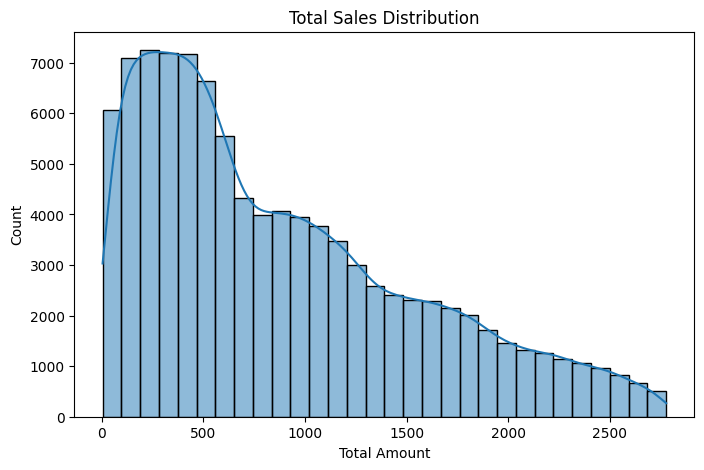

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["TotalAmount"], bins=30, kde=True)

plt.title("Total Sales Distribution")
plt.xlabel("Total Amount")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

# **Total Sales Distribution (Histogram)**
The distribution of total sales is clearly right-skewed, meaning that most transactions fall in the lower price range while only a small number of orders have very high values. The peak of the distribution is concentrated between lower to mid price ranges, and as the total amount increases, the frequency of transactions decreases significantly.

This indicates that the business primarily operates on a high-volume, low-value sales model, where many small purchases contribute to total revenue rather than a few expensive transactions.



# **Findings**
- The distribution of TotalAmount is right-skewed
- Majority of transactions fall in the low sales range
- Few transactions have very high values

# **Insights**
- The business generates most of its orders from low-value purchases
- A small percentage of customers contribute to high revenue (high-value orders)
- Indicates a long-tail revenue pattern

# **Business Impact**
- Focus on upselling and bundling to increase order value
- Identify and retain high-value customers (VIP segment)

# **Sales Spread**

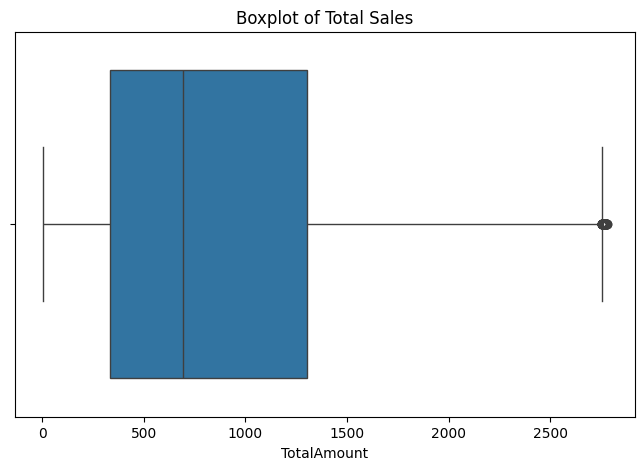

In [9]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["TotalAmount"])

plt.title("Boxplot of Total Sales")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

# **Sales Spread (Boxplot)**
The boxplot shows a wide spread in total sales with several extreme outliers on the higher end. The median value lies closer to the lower range, confirming that most customers spend relatively small amounts.

The presence of high-value outliers suggests that there are premium or bulk purchases, but they are rare compared to normal transactions.

# **Findings**
- Wide spread in TotalAmount values
- Presence of outliers (high-value transactions)

# **Insights**
- Outliers represent bulk purchases or premium product sales
- Sales variability is high, indicating diverse customer behavior

# **Business Impact**
- Create premium product strategies
- Offer discounts on bulk purchases
- Analyze outliers separately for high-value customer insights

# **Categorical Analysis**
#### **Orders by Category**

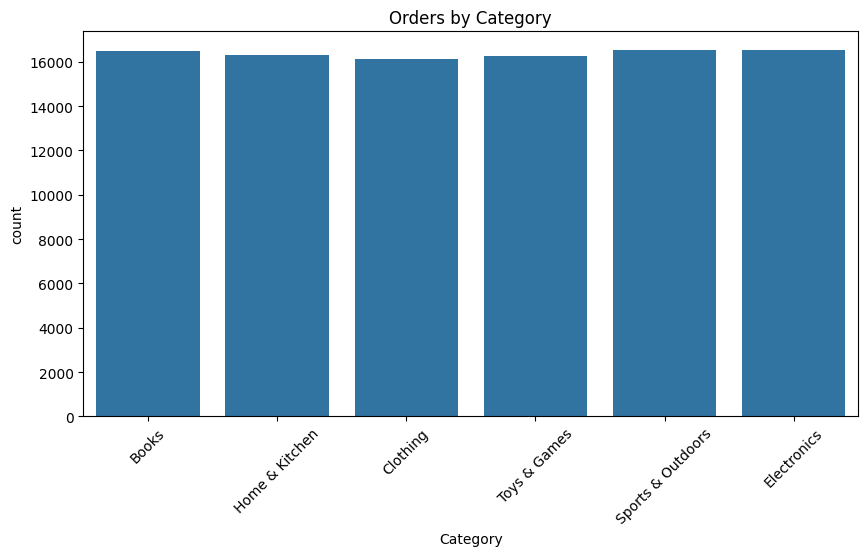

In [10]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Category")

plt.xticks(rotation=45)

plt.title("Orders by Category")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

# **Orders by Category (Countplot)**
The number of orders across categories such as Books, Electronics, Clothing, Home & Kitchen, Toys, and Sports appears to be almost evenly distributed.

No single category dominates the order volume, which indicates a balanced product portfolio.

# **Findings**
- Wide spread in TotalAmount values
- Presence of outliers (high-value transactions)

# **Insights**
- Outliers represent bulk purchases or premium product sales
- Sales variability is high, indicating diverse customer behavior

# **Business Impact**
- Create premium product strategies
- Offer discounts on bulk purchases
- Analyze outliers separately for high-value customer insights

# **Payment Method Distribution**

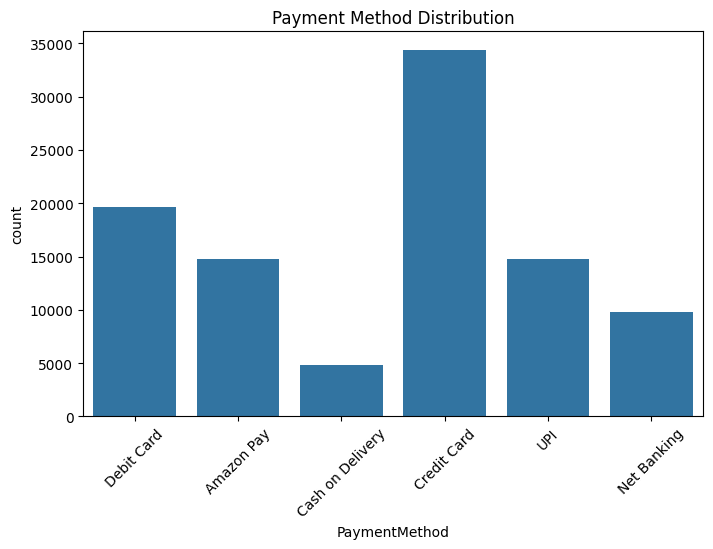

In [11]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="PaymentMethod")

plt.xticks(rotation=45)

plt.title("Payment Method Distribution")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

# **Payment Method Distribution**
The chart shows that Credit Card is the most used payment method, followed by Debit Card, UPI, and others, while Cash on Delivery has the lowest usage.

This clearly indicates a strong preference for digital payment methods.

# **Findings**
- Credit Card is the most used payment method
- Cash on Delivery (COD) is the least used
- Digital payments (UPI, cards, Amazon Pay) dominate

# **Insights**
- Customers prefer fast and secure digital payments
- COD usage is declining

# **Business Impact**
- Promote online payment offers (cashback, discounts)
- Reduce dependency on COD (lower risk, faster processing)
- Improve payment gateway experience

# **Bivariate Analysis**
Category vs Sales

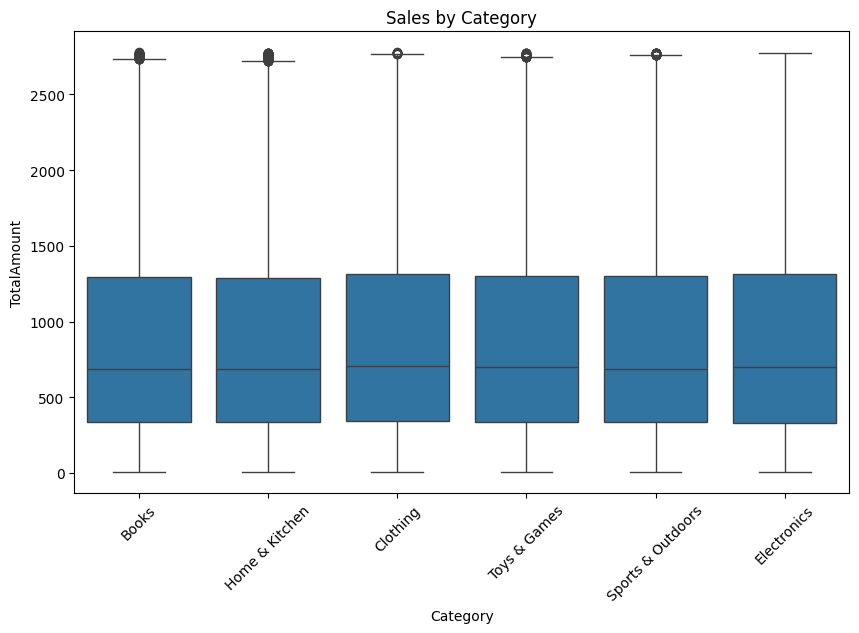

In [12]:
plt.figure(figsize=(10,6))

sns.boxplot(data=df, x="Category", y="TotalAmount")

plt.xticks(rotation=45)

plt.title("Sales by Category")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

### **Category vs Sales (Boxplot)**
The boxplot comparing categories and total sales shows that the median and spread of sales are quite similar across all categories.

This suggests that customer spending behavior does not significantly differ by category.

### **Findings**
- Median sales are similar across categories
- No category shows significantly higher sales distribution

### **Insights**
- Revenue contribution is balanced across categories
- No category is a major revenue driver

### **Business Impact**
- Business is diversified (low risk)
- Can experiment with pricing or promotions per category
- Identify categories with potential for growth optimization

# **Quantity vs Total Sales**

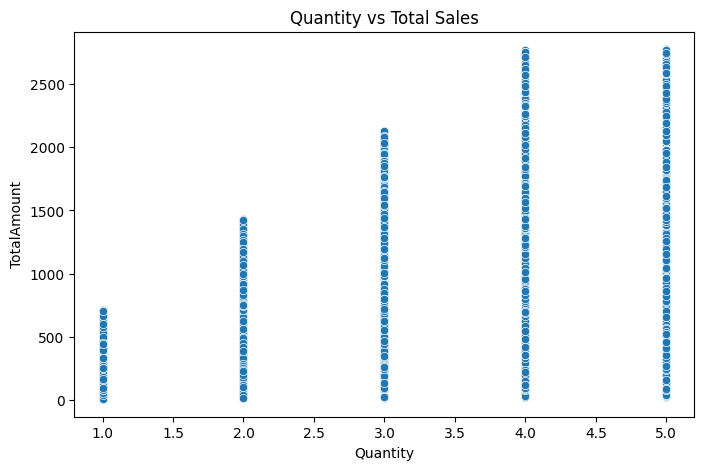

In [13]:

plt.figure(figsize=(8,5))

sns.scatterplot(data=df, x="Quantity", y="TotalAmount")

plt.title("Quantity vs Total Sales")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

Quantity vs Total Sales (Scatter Plot)
The scatter plot shows a strong positive relationship between quantity and total sales. As the quantity increases, the total amount also increases consistently.

This is expected since total sales depend directly on the number of items purchased.

Findings
Strong positive relationship between Quantity and TotalAmount
Insights
As quantity increases, total revenue increases
Customers buying more items generate higher sales
Business Impact
Introduce bundle offers (Buy 2 Get 1)
Encourage bulk purchasing behavior
Increase average order value (AOV)

### **Findings**
- Strong positive relationship between Quantity and TotalAmount

### **Insights**
- As quantity increases, total revenue increases
- Customers buying more items generate higher sales

### **Business Impact**
- Introduce bundle offers (Buy 2 Get 1)
- Encourage bulk purchasing behavior
- Increase average order value (AOV)

### **Correlation Heatmap**

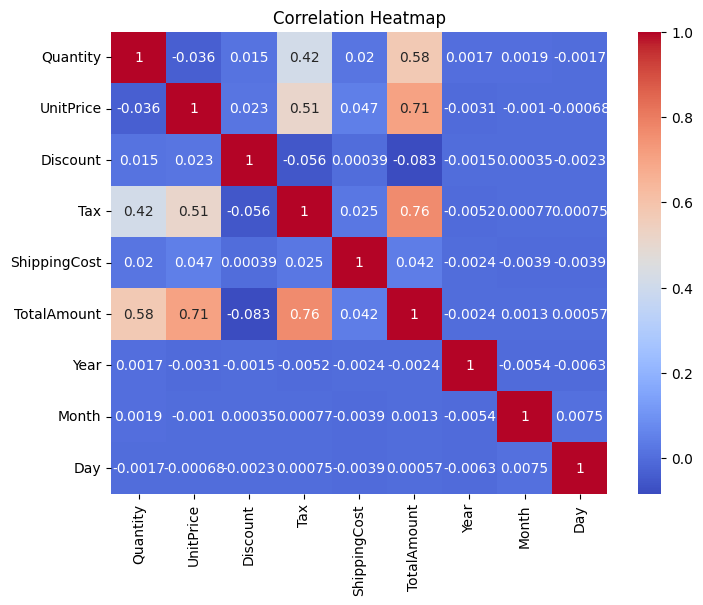

In [15]:
plt.figure(figsize=(8,6))

sns.heatmap(df.select_dtypes(include="number").corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.savefig(r"C:\\Users\\\HP\\Downloads\\Amazon.png")

plt.show()

### **Correlation Heatmap**
The correlation heatmap reveals important relationships:

TotalAmount has strong positive correlation with:

- Tax (~0.77)
- UnitPrice (~0.71)
- Quantity (~0.58)

Discount has very weak or negative correlation with TotalAmount

Shipping cost has minimal impact on total sales

#### **Findings**
- TotalAmount strongly correlated with:
- UnitPrice, Quantity, Tax
- Weak correlation with Discount and ShippingCost

#### **Insights**
- Revenue is mainly driven by price and quantity
- Discounts are not strongly influencing total sales

#### **Business Impact**
- Focus on pricing strategy instead of heavy discounts
- Optimize product pricing and packaging
- Evaluate effectiveness of discount strategies

### **Overall Business Insights**
The analysis shows that the business operates in a stable and balanced environment, with no extreme dependency on categories, payment methods, or regions. The revenue model is primarily driven by frequent small transactions, with a small portion of high-value purchases.

Customer behavior is consistent across categories, and digital payments dominate the transaction ecosystem.

### **Final Recommendations**
- Increase Average Order Value (AOV) using bundles and combos
- Target high-value customers with loyalty programs
- Promote digital payments with incentives
- Use seasonal trends (from time analysis) for campaigns
- Reduce dependency on discounts and focus on pricing strategy
- Encourage bulk purchases to increase quantity per order

### **Conclusion**
The exploratory analysis reveals that while the business handles a large number of low-value transactions, a smaller segment of high-value purchases significantly contributes to revenue. Understanding these patterns can help improve pricing strategies, customer targeting, and overall sales performance.